In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb_lib
import warnings
warnings.filterwarnings('ignore')

# Baca data
df = pd.read_csv('../data/creditcard.csv')

# Pisahkan fitur dan target
X = df.drop('Class', axis=1)
y = df['Class']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE untuk balance class
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Train XGBoost model
xgb = xgb_lib.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_smote, y_train_smote)

print("✓ Model XGBoost sudah dilatih!")

✓ Model XGBoost sudah dilatih!


In [2]:
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Inisialisasi SHAP untuk model XGBoost kita
# TreeExplainer = versi SHAP khusus untuk model berbasis pohon
# seperti XGBoost dan Random Forest
explainer = shap.TreeExplainer(xgb)

print("SHAP explainer siap digunakan!")

SHAP explainer siap digunakan!


In [3]:
# Kita ambil 1000 sampel dari data test supaya tidak terlalu lama
# (menghitung SHAP untuk 56.962 transaksi sekaligus butuh waktu lama)
X_test_sample = pd.DataFrame(
    X_test_scaled[:1000], 
    columns=X.columns
)

# Hitung nilai SHAP untuk 1000 transaksi tersebut
# Ini proses: "Untuk setiap transaksi, kolom mana yang paling 
# berpengaruh terhadap keputusan model?"
shap_values = explainer.shap_values(X_test_sample)

print("Selesai menghitung SHAP values!")
print(f"Ukuran SHAP values: {shap_values.shape}")

Selesai menghitung SHAP values!
Ukuran SHAP values: (1000, 30)


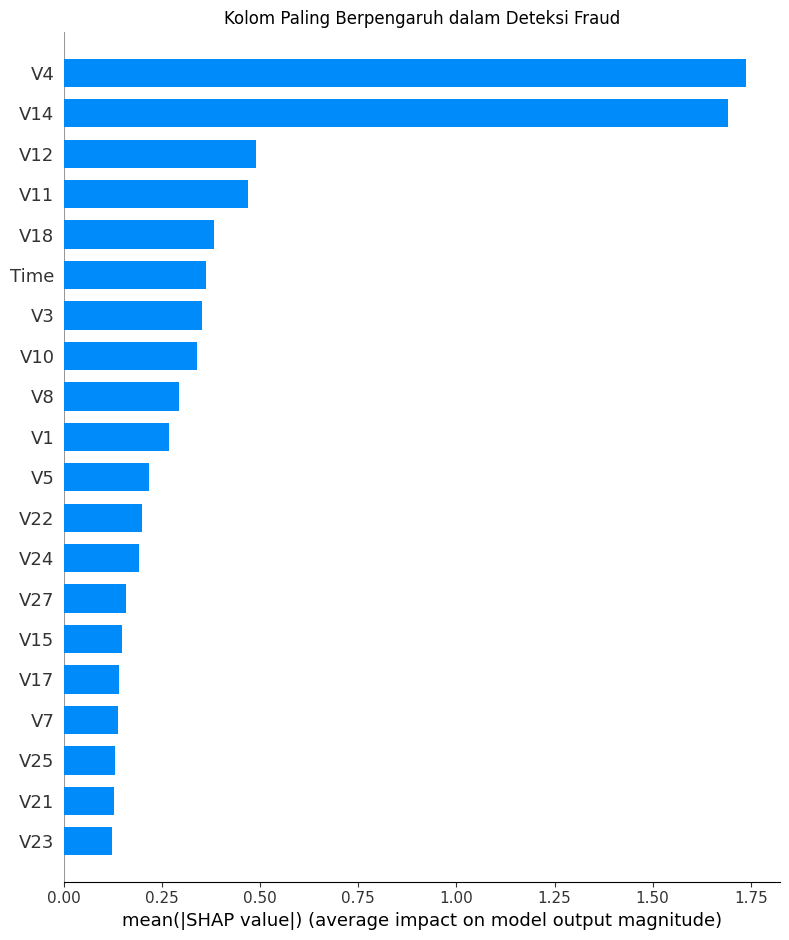

In [4]:
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test_sample,
    plot_type="bar",
    show=False
)
plt.title("Kolom Paling Berpengaruh dalam Deteksi Fraud")
plt.tight_layout()
plt.show()

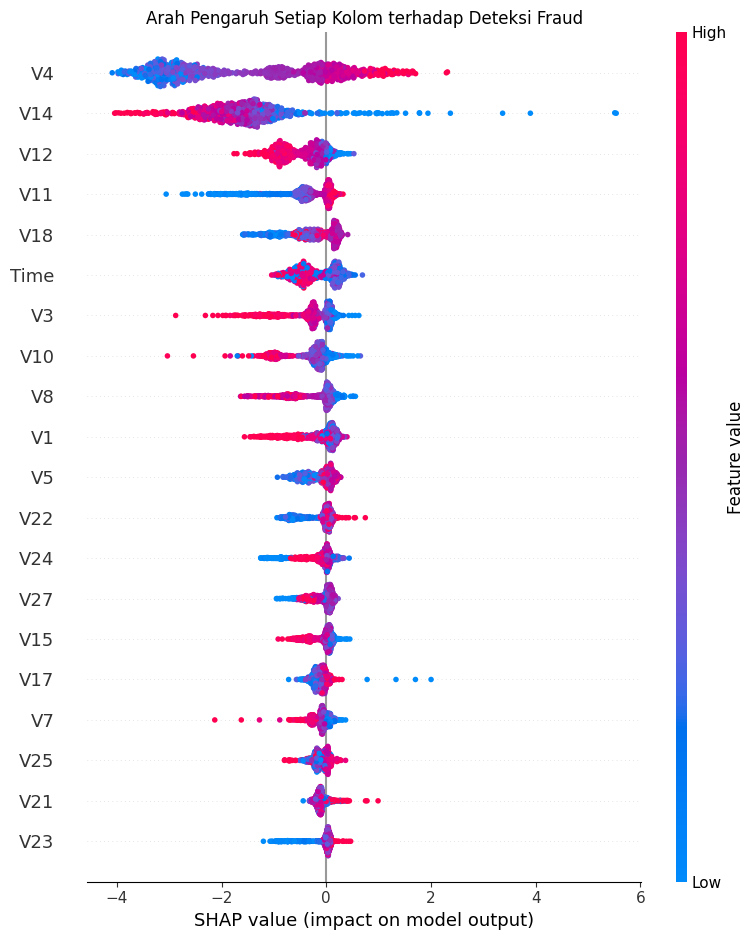

In [5]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_sample,
    show=False
)
plt.title("Arah Pengaruh Setiap Kolom terhadap Deteksi Fraud")
plt.tight_layout()
plt.show()

In [6]:
# Kita cari transaksi fraud pertama di 1000 sampel kita
y_test_sample = y_test.values[:1000]
index_fraud = np.where(y_test_sample == 1)[0][0]

print(f"Transaksi fraud ditemukan di index: {index_fraud}")
print(f"Label aslinya: {'FRAUD' if y_test_sample[index_fraud] == 1 else 'NORMAL'}")
print(f"Prediksi model: {'FRAUD' if xgb.predict(X_test_sample.iloc[[index_fraud]])[0] == 1 else 'NORMAL'}")

Transaksi fraud ditemukan di index: 355
Label aslinya: FRAUD
Prediksi model: FRAUD


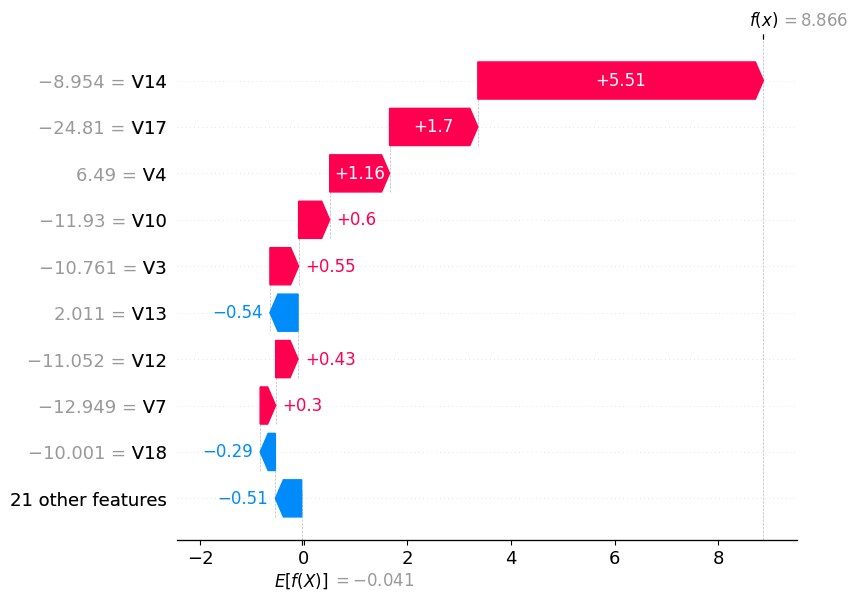

In [7]:
# Waterfall chart = grafik yang menjelaskan keputusan model
# untuk SATU transaksi spesifik secara detail
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[index_fraud],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[index_fraud],
        feature_names=X.columns.tolist()
    )
)

In [8]:
import pickle
import os

# Buat folder models kalau belum ada
os.makedirs('models', exist_ok=True)

# Simpan model XGBoost ke file
# Ibarat kamu sudah masak, sekarang kamu simpan makanannya
# ke dalam wadah supaya bisa dipanaskan lagi nanti
with open('models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Simpan scaler juga — karena input dari user nanti
# harus di-scaling dulu sebelum masuk ke model
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model berhasil disimpan!")
print("File tersimpan di folder models/")

Model berhasil disimpan!
File tersimpan di folder models/


In [1]:
from xgboost import XGBClassifier
import shap

test_model = XGBClassifier()
test_model.load_model('../models/xgboost_model.json')

test_explainer = shap.TreeExplainer(test_model)
print("✓ SHAP berhasil!")

C:\Users\Muhammad Fahri Hamdi\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ SHAP berhasil!
